# Credit Card Fraud Detection using XGBoost

Objective:
Build a machine learning model to detect fraudulent transactions using preprocessing, XGBoost, and threshold optimization.

# 1-Import Libraries

In [3]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score, roc_curve,precision_recall_curve

# 2-Load Data

In [4]:
data=pd.read_csv('fraudTest/fraudTest.csv')


# 3-EDA

In [5]:
data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [6]:
data.info()



<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-null  float64

In [7]:
data.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


# 4-Data Cleaning

In [8]:
data.drop(columns=[
    'Unnamed: 0',
    'trans_num',
    'first',
    'last',
    'street'
], inplace=True)

In [9]:
data.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
gender                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(0)

# 5-Feature Engineering

In [11]:
data['dob'] = pd.to_datetime(data['dob'])
data['age'] = 2026 - data['dob'].dt.year
data['trans_date_trans_time'] = pd.to_datetime(
    data['trans_date_trans_time']
)
data['hour'] = data['trans_date_trans_time'].dt.hour
data['day'] = data['trans_date_trans_time'].dt.day
data['month'] = data['trans_date_trans_time'].dt.month
data['dayofweek'] = data['trans_date_trans_time'].dt.dayofweek
data.drop(columns=[
    'dob',
    'trans_date_trans_time'
], inplace=True)

# 6-Split Features / Target

In [12]:
x=data.drop(['is_fraud'],axis=1)
y=data['is_fraud']

# 7-Train/Test Split

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2,
                                               random_state=42
                                              )

# 8-Preprocessing

In [14]:
numeric_transformer = SimpleImputer(strategy="median")
cat_cols = [
    'merchant',
    'category',
    'gender',
    'city',
    'state',
    'job'
]

num_cols = [
    'amt',
    'zip',
    'lat',
    'long',
    'city_pop',
    'unix_time',
    'merch_lat',
    'merch_long',
    'age',
    'hour',
    'day',
    'month',
    'dayofweek'
]




preprocess = ColumnTransformer([
    
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", numeric_transformer, num_cols)
]
)



# 9-model and pipeline

In [15]:
xgb=XGBClassifier(n_estimators=600,
                  max_depth=5,
                  learning_rate=0.02,
                  scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
                  subsample=0.9,
                  colsample_bytree=0.9,
                  random_state=42
                 )
xgb_model = Pipeline([
 
    ("preprocess", preprocess),
    ("model", xgb)
])
xgb_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['cc_num','merchant','category',...,'day','month','dayofweek']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining c

# 10-Prediction + Probabilities

In [16]:
xgb_pred=xgb_model.predict(x_test)
probs = xgb_model.predict_proba(x_test)[:,1]


# 11-Threshold Optimization 

In [17]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

best_threshold = thresholds[np.argmax(f1)]

print("Best Threshold:", best_threshold)

preds = (probs > best_threshold).astype(int)



Best Threshold: 0.9578745


# 12-Evaluation and Feature importance

In [18]:

print("AUC:", roc_auc_score(y_test, probs))
print(classification_report(y_test, preds))

AUC: 0.9963186938486959
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110718
           1       0.83      0.80      0.82       426

    accuracy                           1.00    111144
   macro avg       0.92      0.90      0.91    111144
weighted avg       1.00      1.00      1.00    111144



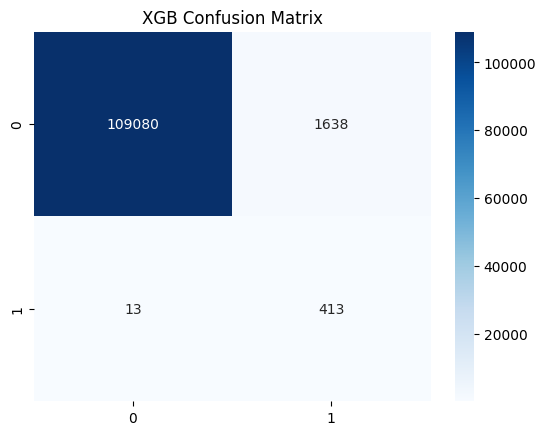

In [19]:

sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt="d",cmap="Blues")
plt.title("XGB Confusion Matrix")
plt.show()

In [24]:
features = xgb_model.named_steps["preprocess"].get_feature_names_out()
importances = xgb_model.named_steps["model"].feature_importances_

feature_names_clean = (
    pd.Index(features)
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)
feat_imp = pd.DataFrame({
    "Feature": feature_names_clean,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(feat_imp.head(10))

                     Feature  Importance
2086                     amt    0.048864
695   category_gas_transport    0.032419
696     category_grocery_net    0.026377
2095                    hour    0.021716
694     category_food_dining    0.018183
699            category_home    0.014513
704    category_shopping_net    0.014280
693   category_entertainment    0.013213
1126            city_Leonard    0.011889
705    category_shopping_pos    0.011528


# 13-SHAP

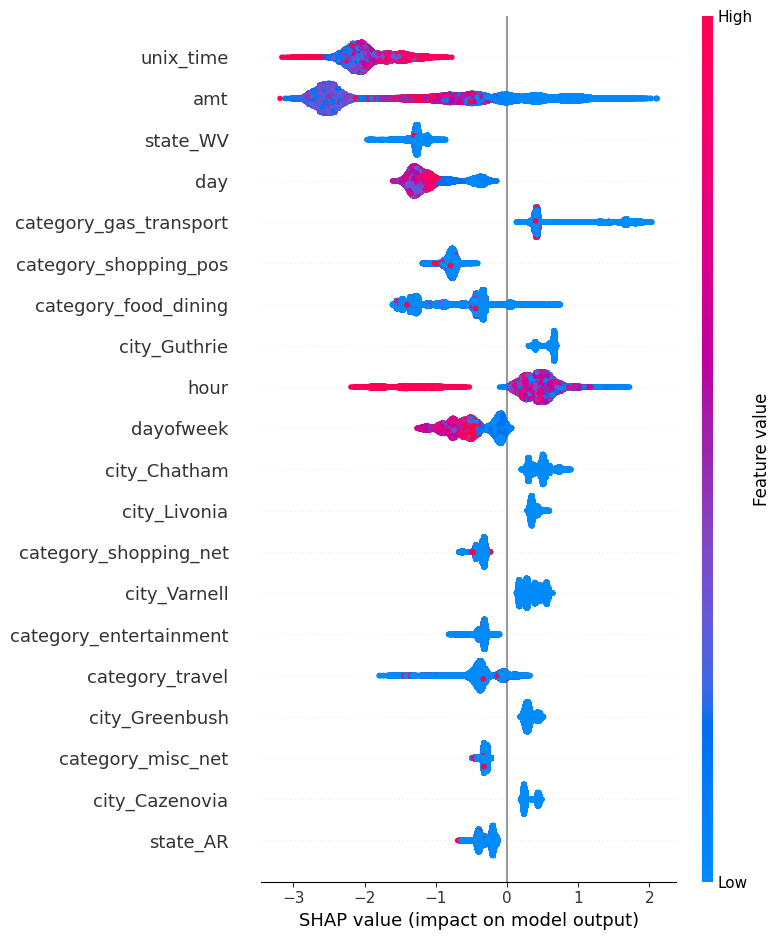

In [25]:

preprocessor = xgb_model.named_steps["preprocess"]
model = xgb_model.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()


feature_names_clean = (
    pd.Index(feature_names)
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)


x_test_encoded = preprocessor.transform(x_test)
if hasattr(x_test_encoded, "toarray"):
    x_test_encoded_dense = x_test_encoded.toarray()  
else:
    x_test_encoded_dense = x_test_encoded


explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test_encoded_dense)


shap.summary_plot(shap_values, x_test_encoded_dense, feature_names=feature_names_clean)

# 14-Save The model

In [26]:
joblib.dump(xgb_model, "model.pkl")
joblib.dump(x_train.columns.tolist(), "features.pkl")
joblib.dump(best_threshold, "threshold.pkl")

['threshold.pkl']

# 15-Business Insights

-The most important feature for fraud detection is transaction amount (amt), indicating that high-value transactions are more likely to be fraudulent.

-Merchant category plays a significant role, with categories such as gas_transport, grocery_net, food_dining, shopping_net, and shopping_pos showing higher importance.

-The transaction hour (hour) is an important temporal factor, suggesting that fraud patterns vary depending on the time of day.

-Certain cities (such as city_Leonard) show higher relevance, indicating geographical patterns in fraud behavior.

-Online transactions, especially shopping_net, are more associated with fraud compared to other transaction types.

# 16-Business Recommendations

-The most important feature for fraud detection is transaction amount (amt), indicating that high-value transactions are more likely to be fraudulent.

-Merchant category plays a significant role, with categories such as gas_transport, grocery_net, food_dining, shopping_net, and shopping_pos showing higher importance.

-The transaction hour (hour) is an important temporal factor, suggesting that fraud patterns vary depending on the time of day.

-Certain cities (such as city_Leonard) show higher relevance, indicating geographical patterns in fraud behavior.

-Online transactions, especially shopping_net, are more associated with fraud compared to other transaction types.

# Conclusion
The fraud detection system successfully identifies key behavioral patterns associated with fraudulent transactions. Transaction amount is the most influential factor, followed by merchant category, transaction timing, and geographic signals.

The model demonstrates strong performance and captures meaningful patterns in financial behavior. These insights can be used to build proactive fraud detection systems and improve financial security through real-time monitoring and risk-based strategies.